In [1]:
import pandas as pd

columns = ['Overall Qual', 'Overall Cond', 'Gr Liv Area', 'Central Air', 'Total Bsmt SF', 'SalePrice']

df = pd.read_csv("http://jse.amstat.org/v19n3/decock/AmesHousing.txt", sep='\t', usecols= columns)
# not that we have limit the columns for the sake of simplicity

df.head()

df["Central Air"] = df["Central Air"].map({'N':0,"Y":1})

#print(df.head())

df = df.dropna(axis= 0) # remove row
df.isnull().sum()

Overall Qual     0
Overall Cond     0
Total Bsmt SF    0
Central Air      0
Gr Liv Area      0
SalePrice        0
dtype: int64

# Evaluating the performance of linear regression models

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

target = 'SalePrice'

features = df.columns[df.columns != target]
X = df[features].values
Y = df[target].values
x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size= 0.3, random_state= 12)

slr = LinearRegression()

slr.fit(x_train, y_train)

y_train_pred = slr.predict(x_train)
y_test_pred = slr.predict(x_test)


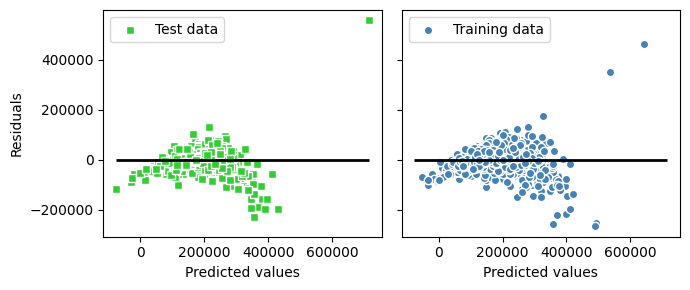

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x_max = np.max([np.max(y_train_pred), np.max(y_test_pred)])
x_min = np.min([np.min(y_train_pred), np.min(y_test_pred)])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), sharey=True)

ax1.scatter(y_test_pred, y_test_pred - y_test,
            c='limegreen', marker='s', edgecolor='white',
            label='Test data')

ax2.scatter(y_train_pred, y_train_pred - y_train,
            c='steelblue', marker='o', edgecolor='white',
            label='Training data')

ax1.set_ylabel('Residuals')
for ax in (ax1, ax2):
    ax.set_xlabel('Predicted values')
    ax.legend(loc='upper left')
    ax.hlines(y=0, xmin=x_min-100, xmax=x_max+100,
              color='black', lw=2)

plt.tight_layout()
plt.show()


# computing MSE from the data above

In [4]:
from sklearn.metrics import mean_squared_error

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
print(mse_test)
print(mse_train)

# mae emphasises on the smaller problems more
from sklearn.metrics import mean_absolute_error

mse_train = mean_absolute_error(y_train, y_train_pred)
mse_test = mean_absolute_error(y_test, y_test_pred)
print(mse_test)
print(mse_train)

# therefore based on the mae we can say that modle makes error of appx on train 25000 dollars

1733665198.2213714
1405359023.8968568
26291.633048389358
25275.058190786236


# evaluating r squared
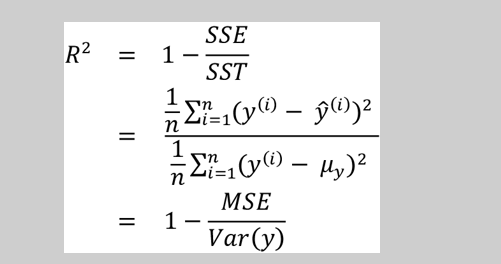

In [5]:
from sklearn.metrics import r2_score

r2_train = r2_score(y_train, y_train_pred)

print(r2_train)

r2_test = r2_score(y_test, y_test_pred)

print(r2_test)


# note the model is not that bad however a test r_squared of train seems to be  overfitting slightly

0.7717977560142935
0.7478748927539013


#  types of regularizatin; for more info visit  http://scikit-learn.org/stable/modules/linear_model.html.

1. Lasso Regression
A regression model which uses the L1 Regularization technique is called LASSO (Least Absolute Shrinkage and Selection Operator) regression. It adds the absolute value of magnitude of the coefficient as a penalty term to the loss function(L)
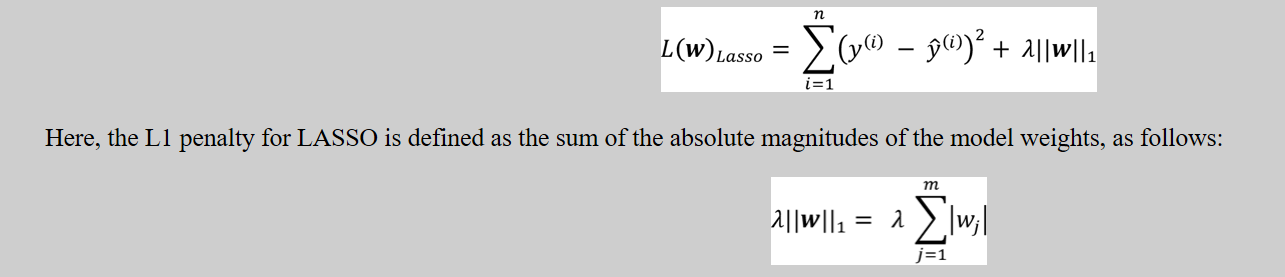
2. Ridge Regression
A regression model that uses the L2 regularization technique is called Ridge regression. It adds the squared magnitude of the coefficient as a penalty term to the loss function(L)
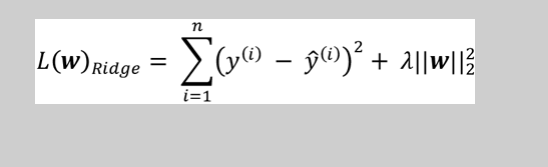
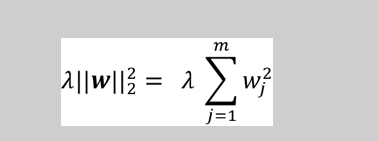
3. Elastic Net Regression
Elastic Net Regression is a combination of both L1 as well as L2 regularization. It combines both L1 (absolute values) and L2 (squared values) penalties on the coefficients. 
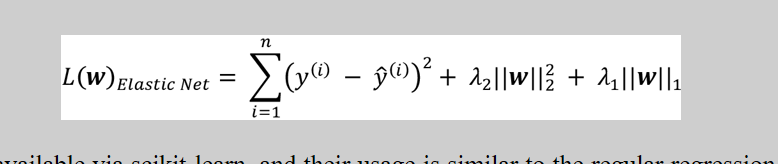

In [6]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=1.0)
elanet = ElasticNet(alpha=1.0, l1_ratio=0.5)



# Turning a linear regression model into a curve – polynomial regression
# Adding polynomial terms using scikit-learn

In [7]:
# adding second degree prolynomial
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
x = np.array([ 258.0, 270.0, 294.0, 320.0, 342.0,368.0, 396.0, 446.0, 480.0, 586.0]) [:,np.newaxis] # note the sklearn expects two dimension so we are feeding the data and then use 2 d

y = np.array([ 236.4, 234.4, 252.8, 298.6, 314.2, 342.2, 360.8, 368.0, 391.2, 390.8])

quadratic = PolynomialFeatures(degree= 2)
x_quad  = quadratic.fit_transform(x) #  \(y = w_0 + w_1x + w_2x^2\).


In [8]:
# fitting linear  model for comparison

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x, y)

x_pre = np.arange(250, 700, 10)[:, np.newaxis]

y_lin_t = lr.predict(x_pre)

In [9]:
# fittinf polynomial


pr = LinearRegression()
pr.fit(x_quad, y)

y_pol_t = pr.predict(quadratic.transform(x_pre))

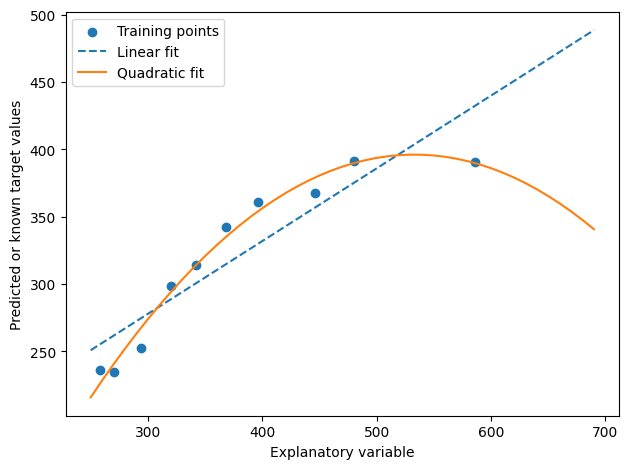

In [10]:
import matplotlib.pyplot as plt

plt.scatter(x, y, label='Training points')
plt.plot(x_pre, y_lin_t, label='Linear fit', linestyle='--')
plt.plot(x_pre, y_pol_t, label='Quadratic fit')
plt.xlabel('Explanatory variable')
plt.ylabel('Predicted or known target values')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [11]:
# calculating MSE and R2 square
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
y_lin_t = lr.predict(x)
y_pol_t = pr.predict(x_quad)

mse_lin = mean_absolute_error(y,y_lin_t)

print(f"the mse for lin {mse_lin}")

mse_pol = mean_absolute_error(y, y_pol_t)

print(f"the mse for pol {mse_pol}")

r2_lin = r2_score(y,y_lin_t)
print(r2_lin)

r2_pol = r2_score(y,y_pol_t)
print(r2_pol)

the mse for lin 21.898155760139353
the mse for pol 6.378821033863164
0.8317053837891232
0.9818850241163604


# MODELLING NON LINEAR RELATIONSHIP

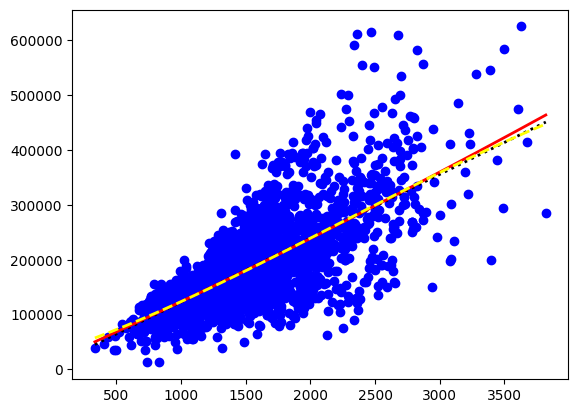

In [ ]:
X = df[['Gr Liv Area']].values
y =  df["SalePrice"].values

X =X[(df['Gr Liv Area'] < 4000)]
y = y[(df["Gr Liv Area"] < 4000)]

regr = LinearRegression()
regr.fit(X, y)

X_fit  = np.arange(X.min() -1, X.max() + 2, 1)[:, np.newaxis]
y_regr_pr = regr.predict(X_fit)

poly_2 = PolynomialFeatures(degree= 2)

X_quad = poly_2.fit_transform(X)

poly_3 = PolynomialFeatures(degree= 3)

X_cubic = poly_3.fit_transform(X)

y_lin_fit = regr.predict(X_fit)

y2_score_lin = r2_score(y,regr.predict(X) )

# time to fit the quadratic

regr = regr.fit(X_quad,y )

y_quad_fit = regr.predict(poly_2.transform(X_fit))

quadratic_score = r2_score(y,regr.predict(X_quad) )

# fitting the cubic

regr.fit(X_cubic, y)

ycubic_fit = regr.predict(poly_3.transform(X_fit))

cubic_score = r2_score(y, regr.predict(X_cubic))


plt.scatter(X,y, c = "blue", label = "training data")

plt.plot(X_fit, y_lin_fit, label=f'Linear (d=1), $R^2$={y2_score_lin:.2f}', color='black', lw=2, linestyle=':')


plt.plot(X_fit, y_quad_fit, label=f'quad (d=2), $R^2$={quadratic_score:.2f}', color='red', lw=2, linestyle='-')


plt.plot(X_fit, ycubic_fit, label=f'ycubic (d=3), $R^2$={cubic_score:.2f}', color='yellow', lw=2, linestyle='--')
# no diffecnce lets try out in values that apppears not that linear 

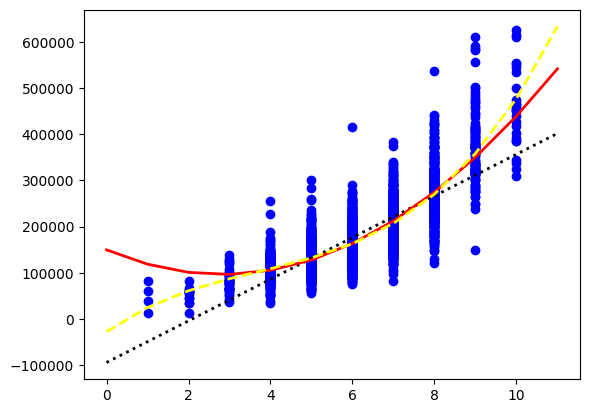

In [17]:
X = df[['Overall Qual']].values
y =  df["SalePrice"].values

X =X[(df['Gr Liv Area'] < 4000)]
y = y[(df["Gr Liv Area"] < 4000)]

regr = LinearRegression()
regr.fit(X, y)

X_fit  = np.arange(X.min() -1, X.max() + 2, 1)[:, np.newaxis]
y_regr_pr = regr.predict(X_fit)

poly_2 = PolynomialFeatures(degree= 2)

X_quad = poly_2.fit_transform(X)

poly_3 = PolynomialFeatures(degree= 3)

X_cubic = poly_3.fit_transform(X)

y_lin_fit = regr.predict(X_fit)

y2_score_lin = r2_score(y,regr.predict(X) )

# time to fit the quadratic

regr = regr.fit(X_quad,y )

y_quad_fit = regr.predict(poly_2.transform(X_fit))

quadratic_score = r2_score(y,regr.predict(X_quad) )

# fitting the cubic

regr.fit(X_cubic, y)

ycubic_fit = regr.predict(poly_3.transform(X_fit))

cubic_score = r2_score(y, regr.predict(X_cubic))


plt.scatter(X,y, c = "blue", label = "training data")

plt.plot(X_fit, y_lin_fit, label=f'Linear (d=1), $R^2$={y2_score_lin:.2f}', color='black', lw=2, linestyle=':')


plt.plot(X_fit, y_quad_fit, label=f'quad (d=2), $R^2$={quadratic_score:.2f}', color='red', lw=2, linestyle='-')


plt.plot(X_fit, ycubic_fit, label=f'ycubic (d=3), $R^2$={cubic_score:.2f}', color='yellow', lw=2, linestyle='--')
# no diffecnce lets try out in values that apppears not that linear 

# Dealing with non linear data using Random Forest

